<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/_train_simclr_har_0.5s_hyperparameter_feintuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperparameter Tuning for SimCLR Pretraining with Keras Tuner


In [2]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 5.1 MB/s eta 0:00:00


In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# For Google Colab
# 1. Clone your repository to go to access your notebook and .py files
!git clone https://github.com/Ziyi-star/Bachelorarbeit.git
# 2. Change working directory to where your notebook and .py files are
import os
os.chdir('/content/Bachelorarbeit/notebooks/training')
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import simclr_utitlities
import transformations
import simclr_models
import sys

import keras_tuner as kt
import tensorflow as tf
import datetime

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

# Load data
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_all/TrainTest/X_train_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_all/TrainTest/y_train_onehot.pkl


working_directory = "../models/"  # Relative path to models folder

# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)

print(np_train_data.shape, np_train_labels.shape)

Cloning into 'Bachelorarbeit'...
remote: Enumerating objects: 482, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 482 (delta 47), reused 59 (delta 28), pack-reused 399 (from 2)
Receiving objects: 100% (482/482), 147.16 MiB | 27.36 MiB/s, done.
Resolving deltas: 100% (272/272), done.
Updating files: 100% (72/72), done.
--2025-09-22 17:58:11--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_all/TrainTest/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6304965 (6.0M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]   6.01M  --.-KB/s    in 0.05s   

2025-09-22 17:58:11 (113 MB/s) 

In [ ]:
# For Vscode
import keras_tuner as kt
import tensorflow as tf
import datetime

import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import sys
import matplotlib.pyplot as plt

sys.path.append('../')   # Add parent directory to Python path
working_directory = "../models/"
with open('../data_all/TrainTest/X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('../data_all/TrainTest/y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)

In [4]:
# Parameters for all experiments

window_size = 50
input_shape = (window_size, 3)

In [5]:
#A parameter for the SimCLR loss function that controls how sharply similarities are measured.
transform_funcs = [
    transformations.time_segment_permutation_transform_improved,
    transformations.channel_shuffle_transform_vectorized
]
#List of data augmentation functions to apply to the input data. Here, only rotation is used.
transformation_function = simclr_utitlities.generate_composite_transform_function_simple(transform_funcs)

0 <function time_segment_permutation_transform_improved at 0x7be8286d9120>
1 <function channel_shuffle_transform_vectorized at 0x7be8286d9080>


## 1. Define the Model Building Function for Keras Tuner

In [6]:
def build_simclr_model(hp):
    # Hyperparameters to tune
    initial_learning_rate = hp.Float('initial_learning_rate', min_value=0.001, max_value=0.1, sampling='log')
    # Give values: 32, 64, 128, 256, 512, 1024, 2048
    batch_size = hp.Choice('batch_size', values=[32 * (2**i) for i in range(7)])
    decay_steps = hp.Int('decay_steps', min_value=500, max_value=5000, step=500)
    temperature = hp.Float('temperature', min_value=0.05, max_value=0.5, step=0.05)

    # Create optimizer with tunable learning rate
    lr_decayed_fn = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=initial_learning_rate,
        decay_steps=decay_steps
    )
    optimizer = tf.keras.optimizers.SGD(lr_decayed_fn)

    # Build the base model and attach the SimCLR head
    base_model = simclr_models.create_base_model(input_shape, model_name="base_model")
    simclr_model = simclr_models.attach_simclr_head(base_model)

    # Return both the model and the hyperparameters we need for training
    return {
        'model': simclr_model,
        'optimizer': optimizer,
        'temperature': temperature,
        'batch_size': batch_size  # Make sure to include batch_size
    }

## 2. Create a Custom Tuner for SimCLR

In [7]:
from keras_tuner import RandomSearch

class SimCLRTuner(RandomSearch):
    def __init__(self, hypermodel, objective, max_trials, directory, project_name=None, **kwargs):
        super(SimCLRTuner, self).__init__(
            hypermodel=hypermodel,
            objective=objective,
            max_trials=max_trials,
            directory=directory,
            project_name=project_name,
            **kwargs
        )

    def run_trial(self, trial, np_train_data, transformation_function, epochs=20, is_transform_vectorized=True):
        # Get hyperparameters for this trial
        hp = trial.hyperparameters

        # Build model with these hyperparameters
        model_info = self.hypermodel.build(hp)
        simclr_model = model_info['model']
        optimizer = model_info['optimizer']
        temperature = model_info['temperature']
        batch_size = model_info['batch_size']

        # Add manual display of hyperparameters before training
        print(f"\nCurrent trial hyperparameters:")
        print(f"- Learning rate: {hp.get('initial_learning_rate')}")
        print(f"- Decay steps: {hp.get('decay_steps')}")
        print(f"- Temperature: {hp.get('temperature')}")
        print(f"- Batch size: {batch_size}")
        print("------------------------------------")

        # Train the model with SimCLR approach
        trained_model, epoch_losses = simclr_utitlities.simclr_train_model(
            simclr_model,
            np_train_data,
            optimizer,
            batch_size,
            transformation_function,
            temperature=temperature,
            epochs=epochs,
            is_trasnform_function_vectorized=is_transform_vectorized,
            verbose=0  # Set to 0 to reduce output during tuning
        )

        # Return the final loss value
        return {'loss': epoch_losses[-1]}

## 3: Define a Wrapper Function for the Full Tuning Process

In [8]:
def tune_simclr(np_train_data, input_shape, transformation_function,
                max_trials=10, epochs_per_trial=20, epochs=200, project_name="simclr_tuning"):

    # Initialize the tuner
    tuner = SimCLRTuner(
        hypermodel=build_simclr_model,
        objective='loss',  # Minimize the contrastive loss
        max_trials=max_trials,
        directory='tuner_results',
        project_name=project_name
    )

    # Start the search
    tuner.search(
        np_train_data=np_train_data,
        transformation_function=transformation_function,
        epochs=epochs_per_trial,
        is_transform_vectorized=True
    )

    # Get best hyperparameters
    best_hp = tuner.get_best_hyperparameters(1)[0]

    # Train final model with best hyperparameters
    model_info = build_simclr_model(best_hp)
    simclr_model = model_info['model']
    optimizer = model_info['optimizer']
    temperature = model_info['temperature']
    batch_size = model_info['batch_size']


    print(f"Training final model with best hyperparameters:")
    print(f"Learning rate: {best_hp.get('initial_learning_rate')}")
    print(f"Decay steps: {best_hp.get('decay_steps')}")
    print(f"Temperature: {best_hp.get('temperature')}")
    print(f"Batch size: {best_hp.get('batch_size')}")

    # Train the final model with the best hyperparameters for the full number of epochs
    final_model, epoch_losses = simclr_utitlities.simclr_train_model(
        simclr_model,
        np_train_data,
        optimizer,
        batch_size,
        transformation_function,
        temperature=temperature,
        epochs=epochs,  # Use the full number of epochs
        is_trasnform_function_vectorized=True,
        verbose=1
    )

    # Return the model and losses without saving
    return final_model, epoch_losses

## 4. Run the Hyperparameter Tuning

Trial 10 Complete [00h 00m 18s]
loss: 12.745932579040527

Best loss So Far: 2.153215169906616
Total elapsed time: 00h 04m 58s
Training final model with best hyperparameters:
Learning rate: 0.0038077368276735763
Decay steps: 4500
Temperature: 0.05
Batch size: 256
epoch: 1 loss: 9.852
epoch: 2 loss: 8.432
epoch: 3 loss: 7.791
epoch: 4 loss: 7.370
epoch: 5 loss: 6.956
epoch: 6 loss: 6.651
epoch: 7 loss: 6.311
epoch: 8 loss: 6.121
epoch: 9 loss: 5.857
epoch: 10 loss: 5.598
epoch: 11 loss: 5.472
epoch: 12 loss: 5.230
epoch: 13 loss: 4.980
epoch: 14 loss: 4.745
epoch: 15 loss: 4.593
epoch: 16 loss: 4.507
epoch: 17 loss: 4.276
epoch: 18 loss: 4.156
epoch: 19 loss: 3.967
epoch: 20 loss: 4.023
epoch: 21 loss: 3.807
epoch: 22 loss: 3.751
epoch: 23 loss: 3.625
epoch: 24 loss: 3.465
epoch: 25 loss: 3.386
epoch: 26 loss: 3.342
epoch: 27 loss: 3.357
epoch: 28 loss: 3.230
epoch: 29 loss: 3.097
epoch: 30 loss: 3.215
epoch: 31 loss: 2.981
epoch: 32 loss: 2.987
epoch: 33 loss: 2.930
epoch: 34 loss: 2.90

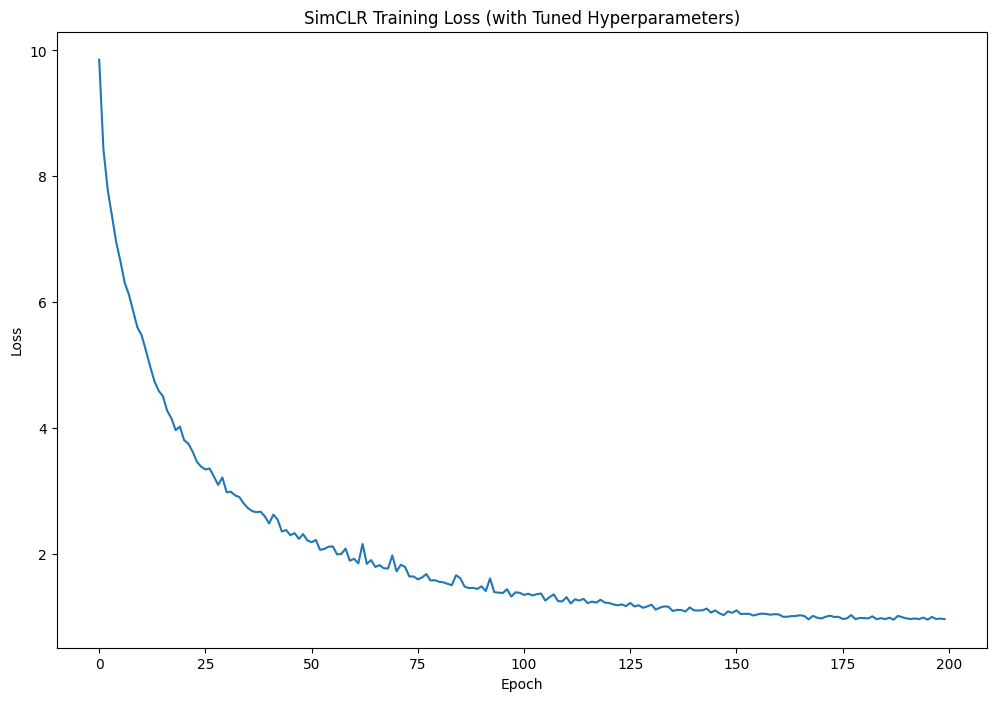

In [9]:
# Set parameters for hyperparameter search
window_size = 50
input_shape = (window_size, 3)
max_trials = 10  # Number of different hyperparameter combinations to try
epochs_per_trial = 50  # Reduced epochs for faster tuning
epochs = 200  # Full epochs for final training

# Run the tuning
final_model, epoch_losses = tune_simclr(
    np_train_data=np_train_data,
    input_shape=input_shape,
    transformation_function=transformation_function,
    max_trials=max_trials,
    epochs_per_trial=epochs_per_trial,
    epochs=epochs,
    project_name="simclr_tuning"
)

# Plot the loss curve for the final model
plt.figure(figsize=(12,8))
plt.plot(epoch_losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.title("SimCLR Training Loss (with Tuned Hyperparameters)")
plt.show()

In [11]:
# Save the final trained model
final_model.save(working_directory + 'simclr_pretrained_model_best.hdf5')